# Mirror-CFE: Chest X-Ray (No Finding vs. Infiltration)

**Paper:** *Looking in the Mirror: A Faithful Counterfactual Explanation Method for Interpreting Deep Image Classification Models* — Chowdhury et al., arXiv:2509.16822

Dieses Notebook wendet **dieselbe Implementierung wie `Mirror_CFE_MNIST_ResNet18.ipynb` / `Mirror_CFE_Fire_ResNet18.ipynb`** auf die [NIH Chest X-rays](https://www.kaggle.com/datasets/nih-chest-xrays/data) an:

- **Klassen** wie in der bestehenden Kaggle-Pipeline (`mirrorcfe-xray.ipynb`): `No Finding` (Klasse 0) vs. alle Befunde, die **Infiltration** enthalten (Klasse 1); Bilder mit anderen Befunden werden verworfen. Ein Klassenpaar: No Finding ↔ Infiltration (in beide Richtungen).
- **Split** ebenfalls identisch: patientenbasiert per `GroupShuffleSplit` (70 % Train, 15 % Val, 15 % Test, `random_state=42`) — kein Patient taucht in mehreren Splits auf.
- **Klassifikator:** gemeinsames torchvision-ResNet-18 (`resnet18_xray_224.pth`, trainiert in `Train_ResNet18_XRay_BestModel.ipynb`) — wird nur **geladen und eingefroren, nicht** im Notebook trainiert. So erklären alle Methoden im Vergleich exakt dasselbe Modell (Fallback: nur wenn der Checkpoint fehlt, wird einer trainiert).
- **Methode unverändert:** Spiegelung der Feature-Maps an der Entscheidungsgrenze (Gl. 1), L-BFGS-Verfeinerung (Suppl. Sec. 7/8), Generator mit Skip-Connection-Controller (SPE + CSP, Gl. 12–14), Verluste Gl. 2–11.

> Im **binären Fall** gilt die Spiegel-Eigenschaft $\mathbf{q}_{(r,s)} = \mathbf{q}_{(s,t)}$ bereits exakt (Sec. 4.1) — die L-BFGS-Verfeinerung ist dann praktisch ein No-Op und konvergiert sofort; der Codepfad bleibt derselbe wie im Mehrklassenfall.

## Gliederung
1. Setup & Konfiguration
2. Daten: NIH Chest X-rays & Klassenpaar
3. Klassifikator $F$: ResNet-18
4. Schrittbasierte CFE-Generierung im Latentraum
5. Architektur: Generator $G$, SSC (SPE + CSP), Diskriminator
6. Verlustfunktionen
7. Training
8. Quantitative Evaluation
9. Visualisierung des CFE-Übergangs
10. Anmerkungen & Designentscheidungen

## 1. Setup & Konfiguration

Hyperparameter wie im Paper (Adam $2\cdot10^{-4}$, $\alpha=0.2$, gleiche Verlustgewichte).

**Ausführung auf einem Cluster:**
- Benötigte Pakete: `torch`, `torchvision`, `matplotlib`, `pillow`, `pandas`, `scikit-learn`, `scipy` (FID), `kagglehub` (Datensatz-Download); optional `lpips` für die LPIPS-Metrik.
- Der Datenpfad wird automatisch erkannt (`/kaggle/input/...` oder kagglehub-Cache); sonst wird der Datensatz einmalig per `kagglehub` heruntergeladen — **Achtung: die vollen NIH Chest X-rays sind ~42 GB.** Liegt der Datensatz bereits auf dem Cluster, den Pfad (Ordner mit `Data_Entry_2017.csv` und `images_*/images/`) in der Umgebungsvariable `MIRROR_XRAY_DATA` setzen.
- Checkpoints landen in `mirror_cfe_checkpoints/`; beim erneuten Ausführen werden sie geladen statt neu trainiert (`RETRAIN_* = True` zum Überschreiben).

**Bildgröße:** Standardmäßig 224×224 — wie in der bestehenden Kaggle-Pipeline; die letzte Feature-Map ist dann 512×7×7. Der Code ist größenunabhängig: Auf schwacher Hardware kann `img_size = 128` gesetzt werden (Paper nutzt 128 für B-MNIST; Feature-Map dann 512×4×4). Auch `epochs_cfe` darf auf dem Cluster gern höher (z. B. 20–30, vgl. Paper: 30 für CelebA-HQ).

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F          # Achtung: der Encoder des Papers heißt ebenfalls F,
import torchvision                        # hier heißt der Klassifikator deshalb `clf`
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

QUICK_TEST = os.environ.get('MIRROR_QUICK', '0') == '1'

# Datenpfad robust finden: erst explizite Angabe, dann auf Kaggle nach der
# Data_Entry_2017.csv suchen (egal unter welchem Mount-Namen), dann lokaler
# kagglehub-Cache. Download NUR ausserhalb von Kaggle (Datensatz ist ~42 GB!).
from glob import glob as _g

def _find_xray_root():
    def ok(c):
        return c and os.path.exists(os.path.join(c, 'Data_Entry_2017.csv'))
    p = os.environ.get('MIRROR_XRAY_DATA', '')
    if ok(p):
        return p
    for base in ('/kaggle/input', '../input'):
        for depth in ('*', '*/*', '*/*/*', '*/*/*/*'):
            for hit in sorted(_g(f'{base}/{depth}/Data_Entry_2017.csv')):
                return os.path.dirname(hit)
    c = os.path.expanduser('/kaggle/input/datasets/organizations/nih-chest-xrays/data')
    return c if ok(c) else None

DATA_DIR = _find_xray_root()
if DATA_DIR is None:
    if os.path.isdir('/kaggle/input/datasets/organizations/nih-chest-xrays/data'):
        raise SystemExit('NIH-Datensatz nicht gefunden. Bitte "nih-chest-xrays/data" '
                         'ueber "+ Add Input" einbinden (auf Kaggle wird bewusst NICHT '
                         'heruntergeladen - der Datensatz ist 42 GB gross).')
    import kagglehub
    print('Lade NIH Chest X-rays herunter (~42 GB) ...')
    DATA_DIR = kagglehub.dataset_download('nih-chest-xrays/data')
print('Datensatz:', DATA_DIR)

NUM_WORKERS = 4 if device.type == 'cuda' else 0   # auf dem Cluster parallel laden

CFG = dict(
    img_size    = 224,                     # wie die bestehende Kaggle-Pipeline (128 als speichersparende Option)
    num_classes = 2,
    class_names = {0: 'No Finding', 1: 'Infiltration'},   # wie in der Vorlage
    batch_size  = 32,
    lr          = 2e-4,                    # Adam (Paper)
    alpha       = 0.2,                     # Triangulationsverlust (Paper)
    rho_range   = (0.3, 0.8),              # [rho_l, rho_u] fuer die CSP-Maske (Gl. 13)
    lambda_tri  = 1.0,
    epochs_classifier = 1 if QUICK_TEST else 3,
    epochs_cfe        = 1 if QUICK_TEST else 8,
    ckpt_dir    = 'mirror_cfe_checkpoints',
)
os.makedirs(CFG['ckpt_dir'], exist_ok=True)

RETRAIN_CLASSIFIER = False
RETRAIN_CFE        = False

suffix    = '_quick' if QUICK_TEST else ''
CLF_CKPT  = os.path.join(CFG['ckpt_dir'], f'resnet18_xray{suffix}.pt')
GEN_CKPT  = os.path.join(CFG['ckpt_dir'], f'mirror_generator_xray{suffix}.pt')
DISC_CKPT = os.path.join(CFG['ckpt_dir'], f'discriminator_xray{suffix}.pt')
if QUICK_TEST:
    print('QUICK_TEST aktiv: reduzierte Daten/Epochen (nur Funktionstest!)')

Device: cuda
Datensatz: /kaggle/input/datasets/organizations/nih-chest-xrays/data


## 2. Daten: NIH Chest X-rays & Klassenpaar

Aufbereitung **identisch zur bestehenden Pipeline** (`mirrorcfe-xray.ipynb`): Aus `Data_Entry_2017.csv` werden nur Bilder mit `No Finding` (Klasse 0) oder einem Befund, der `Infiltration` enthält (Klasse 1), behalten. Der Split ist patientenbasiert (`GroupShuffleSplit`, 70/15/15, `random_state=42`), damit kein Patient gleichzeitig in Training und Test vorkommt. Der CFE-Generator wird auf dem Train-Split trainiert, evaluiert wird auf dem Test-Split (der Klassifikator selbst wird geladen, nicht trainiert).

Die Bilder werden auf `IMG_SIZE`² skaliert und auf $[-1,1]$ normiert (mean/std = 0.5) — dieselbe Normierung, mit der der gemeinsame Klassifikator trainiert wurde; der Generator endet passend mit `tanh`.

In [2]:
import pandas as pd
from glob import glob
from sklearn.model_selection import GroupShuffleSplit

IMG = CFG['img_size']
tfm = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),   # -> [-1, 1]
])

# CSV laden und Binaerlabel zuweisen - identisch zur Vorlage
all_xray_df = pd.read_csv(os.path.join(DATA_DIR, 'Data_Entry_2017.csv'))
all_image_paths = {os.path.basename(x): x
                   for x in glob(os.path.join(DATA_DIR, 'images_*', 'images', '*.png'))}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)
print('Klassenverteilung:')
print(all_xray_df['binary_label'].value_counts()
      .rename(CFG['class_names']).to_string())

# Patientenbasierter Split 70/15/15, random_state 42 - identisch zur Vorlage
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_i, temp_i = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_i].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_i].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_i, test_i = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
test_df = temp_df.iloc[test_i].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0

if QUICK_TEST:
    train_df = train_df.iloc[:256].reset_index(drop=True)
    test_df  = test_df.iloc[:128].reset_index(drop=True)

class XRayDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.targets = self.df['binary_label'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row['path']).convert('RGB')
        return self.transform(img), int(row['binary_label'])

train_ds = XRayDataset(train_df, tfm)
test_ds  = XRayDataset(test_df, tfm)

pair_train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                               shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
pair_test_loader  = DataLoader(test_ds, batch_size=64,
                               shuffle=False, num_workers=NUM_WORKERS)

# binaeres Klassenpaar: No Finding <-> Infiltration
pair_of = {0: 1, 1: 0}

# Index-Pools je Klasse (Trainingssplit) fuer x_t / x_ss im Triangulationsverlust
class_pool = {c: [i for i, y in enumerate(train_ds.targets) if y == c] for c in (0, 1)}

def sample_class_images(labels):
    """Zieht zu jedem Label ein zufaelliges echtes Trainingsbild dieser Klasse."""
    idx = [random.choice(class_pool[int(c)]) for c in labels]
    return torch.stack([train_ds[i][0] for i in idx])

print(f'Train: {len(train_ds)} | Test: {len(test_ds)}')

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Train: 56768 | Test: 11561


## 3. Klassifikator $F$: ResNet-18

Torchvision-ResNet-18 mit Standard-Stem (7×7-Faltung + MaxPool) für RGB-Bilder. Bei 224×224-Eingaben ist die letzte Feature-Map $\mathbf{f}^l$ **512×7×7**; alle Methoden-Bausteine sind größenunabhängig. Skip-Features: $\mathbf{f}^1$ (64×56×56), $\mathbf{f}^2$ (128×28×28), $\mathbf{f}^3$ (256×14×14).

In [3]:
class ResNet18XRay(nn.Module):
    """Torchvision-ResNet-18 (Standard-Stem) mit Feature-Zugriff wie in der MNIST-Version."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.base = torchvision.models.resnet18(weights=None, num_classes=num_classes)

    def features(self, x):
        """[f1, f2, f3, f4]: (64,56,56), (128,28,28), (256,14,14), (512,7,7) bei 224er-Eingabe."""
        b = self.base
        x = b.maxpool(b.relu(b.bn1(b.conv1(x))))
        f1 = b.layer1(x)
        f2 = b.layer2(f1)
        f3 = b.layer3(f2)
        f4 = b.layer4(f3)
        return [f1, f2, f3, f4]

    def encode(self, x):
        """z = GAP(f^l)"""
        return self.features(x)[-1].mean(dim=(2, 3))

    def forward(self, x):
        return self.base.fc(self.encode(x))

clf = ResNet18XRay(CFG['num_classes']).to(device)
print(sum(p.numel() for p in clf.parameters()) / 1e6, 'Mio. Parameter')

11.177538 Mio. Parameter


In [ ]:
def test_accuracy(model, loader):
    model.eval()
    correct = total = 0
    per_class = {0: [0, 0], 1: [0, 0]}
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += len(y)
            for c in (0, 1):
                m = y == c
                per_class[c][0] += (pred[m] == c).sum().item()
                per_class[c][1] += int(m.sum())
    return correct / total, {c: v[0] / max(v[1], 1) for c, v in per_class.items()}

# Es wird IMMER der gemeinsame, vortrainierte Klassifikator (aus Train_ResNet18_*.ipynb)
# geladen, damit alle Methoden im Vergleich exakt dasselbe Modell erklaeren.
# Wird kein solcher Checkpoint gefunden, bricht das Notebook bewusst ab -
# der Klassifikator wird hier NIE selbst trainiert.
from glob import glob as _glob
SHARED_CLF = next((p for p in (['resnet18_xray_224.pth', '/kaggle/input/models/alexandernigg/xray-cnn-final/pytorch/default/1/resnet18_xray_224.pth']
                               + sorted(sum((_glob(f'/kaggle/input/{d}/resnet18_xray_224.pth')
                                             for d in ('*', '*/*', '*/*/*')), [])))
                   if os.path.exists(p)), None)
if SHARED_CLF is None:
    raise FileNotFoundError(
        'Kein vortrainierter Klassifikator gefunden (resnet18_xray_224.pth). '
        'Bitte den gemeinsamen Checkpoint aus Train_ResNet18_*.ipynb bereitstellen - '
        'es wird bewusst kein Klassifikator im Notebook trainiert.')
_ck = torch.load(SHARED_CLF, map_location=device, weights_only=False)
_sd = _ck.get('model_state_dict', _ck) if isinstance(_ck, dict) else _ck
# beide Key-Layouts zulassen (mit/ohne 'base.'-Praefix des Wrappers)
_sd = {k.replace('base.', '', 1): v for k, v in _sd.items()}
clf.base.load_state_dict(_sd)
print('Gemeinsamer Klassifikator geladen:', SHARED_CLF)

acc, per_class = test_accuracy(clf, pair_test_loader)
print(f'Test-Genauigkeit: {acc:.4f} | No Finding: {per_class[0]:.4f} | Infiltration: {per_class[1]:.4f}')

# Klassifikator einfrieren: F ist reiner Encoder/Entscheider und wird NIE feinjustiert (Faithfulness).
for p in clf.parameters():
    p.requires_grad_(False)
clf.eval()

W_fc = clf.base.fc.weight.detach()   # W  (2 x 512)
b_fc = clf.base.fc.bias.detach()     # b  (2)

### Klassifikator-Export für andere Methoden

Der trainierte ResNet-18 wird zusätzlich als **portabler Checkpoint** unter `trained_classifiers/` gespeichert: ein reiner torchvision-`state_dict` (ohne Wrapper-Präfix) plus Metadaten (Bildgröße, Normierung, Klassennamen, Split, Genauigkeit). Andere Methoden (z. B. Wachter, CFProto, FCVE) können ihn so laden:

```python
import torch, torchvision
ckpt  = torch.load('trained_classifiers/resnet18_xray_224.pth', map_location='cpu')
model = torchvision.models.resnet18(num_classes=len(ckpt['class_names']))
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
# Eingaben: RGB, ckpt['img_size']², normiert mit ckpt['normalization_mean']/_std (also [-1,1])
```

In [5]:
# Portabler Export: reiner torchvision-state_dict + Metadaten, damit derselbe
# Klassifikator auch von anderen (CFE-)Methoden wiederverwendet werden kann.
os.makedirs('trained_classifiers', exist_ok=True)
EXPORT_PATH = os.path.join('trained_classifiers', f'resnet18_xray_{IMG}{suffix}.pth')
torch.save({
    'model_state_dict': {k.replace('base.', '', 1): v.cpu()
                          for k, v in clf.state_dict().items()},
    'arch': 'torchvision resnet18(num_classes=2)',
    'dataset': 'NIH Chest X-rays (No Finding=0 / Infiltration=1, wie mirrorcfe-xray.ipynb)',
    'img_size': IMG,
    'normalization_mean': [0.5, 0.5, 0.5],
    'normalization_std':  [0.5, 0.5, 0.5],
    'class_names': CFG['class_names'],
    'split': 'patientenbasiert 70/15/15, GroupShuffleSplit(random_state=42)',
    'test_accuracy': acc,
    'per_class_accuracy': per_class,
}, EXPORT_PATH)
print('Klassifikator exportiert:', EXPORT_PATH)

Klassifikator exportiert: trained_classifiers/resnet18_xray_224.pth


## 4. Schrittbasierte CFE-Generierung im Latentraum

Identisch zur MNIST-Version: ortsweise Spiegelung der Feature-Map $\mathbf{f}^l_s$ an der Hyperebene $(\mathbf{W}_m, \mathbf{b}_m) = (\mathbf{W}_t - \mathbf{W}_s,\ \mathbf{b}_t - \mathbf{b}_s)$ (Gl. 1, Referenzfunktion aus `mirror_cfe.py`), danach L-BFGS-Verfeinerung des GAP-Vektors $\mathbf{z}_r$ auf getauschte $s/t$-Logits (Suppl. Sec. 7) und Verteilung des Deltas auf alle Ortspositionen (Suppl. Sec. 8). KFE-Punkte: $\mathbf{f}^l_k = \mathbf{f}^l_s + k(\mathbf{f}^l_r - \mathbf{f}^l_s)$.

In [6]:
def batch_mirror_points(x0_batch, W_batch, b_batch):
    """Ortsweise Spiegelung der Feature-Maps an der Entscheidungsgrenze (Gl. 1).

    Uebernommen aus dem Original-Code (mirror_cfe.py).
    x0_batch: (B, C, h, w) Feature-Maps, W_batch: (B, C), b_batch: (B,)
    """
    batch_size, feature_dim, h, w = x0_batch.shape
    x0 = x0_batch.reshape(batch_size, feature_dim, -1)
    W  = W_batch.reshape(batch_size, feature_dim, 1)
    b  = b_batch.reshape(batch_size, 1, 1)

    dot_product   = torch.bmm(W.transpose(1, 2), x0)              # (B, 1, h*w)
    norm_W_squared = torch.sum(W * W, dim=1, keepdim=True)        # (B, 1, 1)
    projection = x0 - (dot_product + b) / norm_W_squared * W      # z_p  (k = 0.5)
    mirrored_points = 2 * projection - x0                         # z_r  (k = 1.0)
    return (mirrored_points.reshape(batch_size, feature_dim, h, w),
            projection.reshape(batch_size, feature_dim, h, w))


def get_mirror_points(classifier, mirror_point_fv, pred_source_logits,
                      source_labels, cfe_labels, num_iterations=10, lr=0.1):
    """L-BFGS-Verfeinerung des Reflexionspunkts z_r (Suppl. Sec. 7).

    Ziel: Logits des Reflexionspunkts = Quell-Logits mit vertauschten s/t-Eintraegen.
    Optimiert wird der Vektor z_r = GAP(f_r) auf der CPU (L-BFGS ist dort um
    Groessenordnungen schneller); das Delta wird gleichmaessig auf alle
    Ortspositionen verteilt (Suppl. Sec. 8). Im binaeren Fall ist die Spiegelung
    bereits exakt und die Verfeinerung konvergiert sofort.
    """
    swapped_logits = pred_source_logits.detach().cpu().clone()
    ar = torch.arange(cfe_labels.shape[0])
    s_cpu, t_cpu = source_labels.cpu(), cfe_labels.cpu()
    tmp = swapped_logits[ar, t_cpu].clone()
    swapped_logits[ar, t_cpu] = swapped_logits[ar, s_cpu]
    swapped_logits[ar, s_cpu] = tmp

    W_cpu = classifier.base.fc.weight.detach().cpu()
    b_cpu = classifier.base.fc.bias.detach().cpu()
    z0 = mirror_point_fv.mean(dim=(2, 3)).detach().cpu()   # Initialisierung: GAP der Spiegelung
    z = z0.clone().requires_grad_(True)
    optimizer = torch.optim.LBFGS([z], lr=lr)

    def closure():
        optimizer.zero_grad()
        loss = torch.norm(z @ W_cpu.T + b_cpu - swapped_logits) ** 2
        loss.backward()
        return loss

    with torch.enable_grad():
        for _ in range(num_iterations):
            optimizer.step(closure)

    delta = (z.detach() - z0).to(mirror_point_fv.device)
    return mirror_point_fv + delta.view(delta.shape[0], -1, 1, 1)


def compute_reflection(classifier, f_s4, y_s, y_t):
    """Berechnet den verfeinerten Reflexionspunkt f_r^l (Feature-Map) fuer einen Batch."""
    W_m = (W_fc[y_t] - W_fc[y_s])          # Spiegel: W_t - W_s   (B, 512)
    b_m = (b_fc[y_t] - b_fc[y_s])
    f_mirror, _ = batch_mirror_points(f_s4.detach(), W_m, b_m)
    l_s = classifier.base.fc(f_s4.mean(dim=(2, 3)))
    return get_mirror_points(classifier, f_mirror, l_s.detach(), y_s, y_t)


def kfe_feature(f_s4, f_r4, k):
    """f_k^l = f_s^l + k (f_r^l - f_s^l)  (Suppl. Sec. 8)."""
    return f_s4 + k.view(-1, 1, 1, 1) * (f_r4 - f_s4)

**Sanity-Check:** Am Reflexionspunkt ($k{=}1$) sollte die Zielklassen-Konfidenz der ursprünglichen Quellklassen-Konfidenz entsprechen, an der Projektion ($k{=}0.5$) sollten beide Klassen gleich wahrscheinlich sein (im binären Fall exakt 0.5).

In [7]:
x_demo, y_demo = next(iter(pair_test_loader))
x_demo, y_demo = x_demo.to(device)[:32], y_demo.to(device)[:32]
with torch.no_grad():
    keep = clf(x_demo).argmax(1) == y_demo
x_demo, y_demo = x_demo[keep], y_demo[keep]
t_demo = 1 - y_demo

with torch.no_grad():
    f_s4_demo = clf.features(x_demo)[-1]
f_r4_demo = compute_reflection(clf, f_s4_demo, y_demo, t_demo)

ar = torch.arange(len(y_demo))
for k_val in (0.0, 0.5, 1.0):
    k = torch.full((len(y_demo),), k_val, device=device)
    with torch.no_grad():
        p = torch.softmax(clf.base.fc(kfe_feature(f_s4_demo, f_r4_demo, k).mean((2, 3))), 1)
    print(f'k={k_val:.1f}:  p(Quelle)={p[ar, y_demo].mean():.3f}   p(Ziel)={p[ar, t_demo].mean():.3f}')

k=0.0:  p(Quelle)=0.684   p(Ziel)=0.316
k=0.5:  p(Quelle)=0.500   p(Ziel)=0.500
k=1.0:  p(Quelle)=0.316   p(Ziel)=0.684


## 5. Architektur: Generator $G$, SSC (SPE + CSP), Diskriminator

Wie in der MNIST-Version (Fig. 2 des Papers): SPE-Module editieren die Skip-Connections (Gl. 12), die CAM-gesteuerte CSP-Maske begrenzt die Änderungsregion (Gl. 13), Mischung nach Gl. 14. Der Decoder hat zwei zusätzliche Upsampling-Stufen ohne Skip (der ResNet-Stem reduziert um Faktor 4, bevor `layer1` beginnt) und endet mit 3 Kanälen (`tanh`).

In [8]:
class SPE(nn.Module):
    """Spatial Pattern Editor (Gl. 12): u_k^i = D_i(concat(B_i(f_s^i), f_k^l)).

    Kanalexpansion erst NACH dem Downsampling, damit die Aktivierungen klein
    bleiben (wichtig bei wenig GPU-/Unified-Memory).
    """

    def __init__(self, c_in, size_in, c_lat=512, c_mid=128, size_lat=7):
        super().__init__()
        self.B = nn.Sequential(                       # Bottleneck B_i
            nn.Conv2d(c_in, c_mid, 3, padding=1), nn.ReLU(inplace=True),
            # auf die Aufloesung von f_k^l bringen (224 -> 7x7, 128 -> 4x4)
            nn.Upsample(size=size_lat, mode='bilinear', align_corners=False),
            nn.Conv2d(c_mid, c_lat, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.D = nn.Sequential(                       # Decoder D_i
            nn.Conv2d(2 * c_lat, c_mid, 3, padding=1), nn.ReLU(inplace=True),
            nn.Upsample(size=size_in, mode='bilinear', align_corners=False),
            nn.Conv2d(c_mid, c_mid, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(c_mid, c_in, 3, padding=1),
        )

    def forward(self, f_s_i, f_k_l):
        return self.D(torch.cat([self.B(f_s_i), f_k_l], dim=1))


def csp_mask(f_k_l, W, y_s, y_t, k, rho_range, out_size):
    """CAM-guided Spatial Prior (Gl. 13): binaere Maske aus Quell- und Ziel-CAM."""
    U = torch.einsum('cn,bnhw->bchw', W, f_k_l)                   # unnormierte CAMs
    N = U.clamp(min=0)
    N = N / (N.amax(dim=(2, 3), keepdim=True) + 1e-8)
    ar = torch.arange(f_k_l.shape[0], device=f_k_l.device)
    rho = torch.clamp(1.0 - k, rho_range[0], rho_range[1]).view(-1, 1, 1)
    M = ((N[ar, y_s] > rho) | (N[ar, y_t] > rho)).float().unsqueeze(1)
    return F.interpolate(M, size=out_size, mode='nearest')


class UpBlock(nn.Module):
    def __init__(self, c_in, c_skip, c_out, size_out):
        super().__init__()
        self.up = nn.Upsample(size=size_out, mode='bilinear', align_corners=False)
        self.conv = nn.Sequential(
            nn.Conv2d(c_in + c_skip, c_out, 3, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        return self.conv(torch.cat([self.up(x), skip], dim=1))


class MirrorGenerator(nn.Module):
    """Mapping-Funktion G: Z -> I mit Skip-Connection-Controller (Fig. 2)."""

    def __init__(self, img_size=224, rho_range=(0.3, 0.8)):
        super().__init__()
        self.rho_range = rho_range
        s = img_size // 4                 # Aufloesung von f1 (nach Stem: /4)
        lat = img_size // 32              # Aufloesung von f^l_k (224 -> 7, 128 -> 4)
        # Skip-Layer: f1 (64, s, s), f2 (128, s/2, s/2), f3 (256, s/4, s/4)
        self.spe1 = SPE(64, s, size_lat=lat)
        self.spe2 = SPE(128, s // 2, size_lat=lat)
        self.spe3 = SPE(256, s // 4, size_lat=lat)
        self.bottom = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True))
        self.up3 = UpBlock(256, 256, 128, s // 4)
        self.up2 = UpBlock(128, 128, 64, s // 2)
        self.up1 = UpBlock(64, 64, 64, s)
        # Stem-Reduktion (/4) ohne Skips wieder aufloesen: s -> 2s -> 4s = img_size
        self.head = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(16, 3, 3, padding=1), nn.Tanh(),
        )

    def forward(self, feats_s, f_k_l, y_s, y_t, k, W):
        f1, f2, f3, _ = feats_s
        edited = []
        for f_i, spe in ((f1, self.spe1), (f2, self.spe2), (f3, self.spe3)):
            u_i = spe(f_i, f_k_l)                                             # Gl. 12
            M_i = csp_mask(f_k_l, W, y_s, y_t, k, self.rho_range, f_i.shape[-2:])  # Gl. 13
            edited.append((1 - M_i) * f_i + M_i * u_i)                        # Gl. 14
        e1, e2, e3 = edited
        x = self.bottom(f_k_l)
        x = self.up3(x, e3)
        x = self.up2(x, e2)
        x = self.up1(x, e1)
        return self.head(x)


class Discriminator(nn.Module):
    """PatchGAN-artiger Diskriminator fuer den adversariellen Verlust (Gl. 3)."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),                          # 64
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),   # 32
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),  # 16
            nn.Conv2d(256, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),  # 8
            nn.Conv2d(256, 1, 4, 1, 0))                                                          # 5x5 Patches

    def forward(self, x):
        return self.net(x).flatten(1).mean(1)


gen  = MirrorGenerator(CFG['img_size'], CFG['rho_range']).to(device)
disc = Discriminator().to(device)
print(f'Generator: {sum(p.numel() for p in gen.parameters())/1e6:.1f} Mio. Parameter, '
      f'Diskriminator: {sum(p.numel() for p in disc.parameters())/1e6:.1f} Mio. Parameter')

Generator: 9.0 Mio. Parameter, Diskriminator: 1.7 Mio. Parameter


## 6. Verlustfunktionen (Gl. 2–11)

Unverändert aus der MNIST-Version: Klassifikationsverlust (KLD, Gl. 2), adversarieller Verlust (Gl. 3), Rekonstruktionsverlust (Gl. 4), Feature-Rekonstruktionsverlust (Gl. 5) und Triangulationsverlust (Gl. 6–11) mit $\beta$/$\gamma$ aus dem Latentraum und Relaxierung $\alpha = 0.2$.

In [9]:
bce = nn.BCEWithLogitsLoss()

def kld(p_hat, p, eps=1e-8):
    """KLD(p_hat, p) = sum p_hat * log(p_hat / p)   (Gl. 2)"""
    return (p_hat * ((p_hat + eps).log() - (p + eps).log())).sum(dim=1).mean()

def l1_img(a, b):
    """Mittlere L1-Distanz pro Bild (pro Sample ein Skalar)."""
    return (a - b).abs().flatten(1).mean(dim=1)

def triangulation_loss(x_s, x_k, k, x_t, z_t, x_ss, z_ss, z_s, z_k, alpha):
    """Gl. 6-11: haelt |x_s - x_k| in den Schranken, die der Latentraum vorgibt."""
    is_cfe = (k >= 0.5)
    x_ref = torch.where(is_cfe.view(-1, 1, 1, 1), x_t, x_ss)   # x_t fuer CFE, x_ss fuer SFE
    z_ref = torch.where(is_cfe.view(-1, 1), z_t, z_ss)

    d_sk   = l1_img(x_s, x_k)
    d_kref = l1_img(x_k, x_ref)

    ratio = ((z_k - z_ref).norm(dim=1) /
             ((z_s - z_k).norm(dim=1) + 1e-8)).detach().clamp(1e-3, 1e3)

    lower = (1 - alpha) / ratio * d_kref
    upper = (1 + alpha) / ratio * d_kref
    return (F.relu(lower - d_sk) + F.relu(d_sk - upper)).mean()

## 7. Training

Ablauf wie in der MNIST-Version: eingefrorener Klassifikator, Reflexionspunkt pro Batch, zufälliges $k \sim U[0,1]$ je Sample, Generator-/SSC-Update mit allen fünf Verlusten (gleiche Gewichte), Diskriminator-Update; Quell- und Ziel-Rekonstruktion im Wechsel pro Schritt.

In [10]:
opt_g = torch.optim.Adam(gen.parameters(),  lr=CFG['lr'], betas=(0.5, 0.999))
opt_d = torch.optim.Adam(disc.parameters(), lr=CFG['lr'], betas=(0.5, 0.999))

history = {n: [] for n in ['L_cls', 'L_adv', 'L_rec', 'L_fea', 'L_tri', 'L_D']}

if os.path.exists(GEN_CKPT) and not RETRAIN_CFE:
    gen.load_state_dict(torch.load(GEN_CKPT, map_location=device))
    disc.load_state_dict(torch.load(DISC_CKPT, map_location=device))
    print('Generator/Diskriminator aus Checkpoint geladen - Training uebersprungen.')
else:
    import time
    for epoch in range(CFG['epochs_cfe']):
        gen.train(); disc.train()
        t0 = time.time()
        for step, (x_s, y_s) in enumerate(pair_train_loader):
            x_s, y_s = x_s.to(device), y_s.to(device)
            y_t = 1 - y_s                                          # binaeres Paar
            x_t  = sample_class_images(y_t.tolist()).to(device)    # echte Zielklassenbilder
            x_ss = sample_class_images(y_s.tolist()).to(device)    # zufaellige Quellklassenbilder

            with torch.no_grad():
                feats_s = clf.features(x_s)
                feats_t = clf.features(x_t)
                f_s4, f_t4 = feats_s[3], feats_t[3]
                z_s, z_t = f_s4.mean((2, 3)), f_t4.mean((2, 3))
                z_ss = clf.encode(x_ss)
                p_s = torch.softmax(clf.base.fc(z_s), 1)
                p_t = torch.softmax(clf.base.fc(z_t), 1)

            f_r4 = compute_reflection(clf, f_s4, y_s, y_t)
            k = torch.rand(x_s.size(0), device=device)
            f_k4 = kfe_feature(f_s4, f_r4, k)
            z_k = f_k4.mean((2, 3))
            with torch.no_grad():
                p_k = torch.softmax(clf.base.fc(z_k), 1)
            k0 = torch.zeros_like(k)

            # ---------------- Generator-/SSC-Update ----------------
            x_k = gen(feats_s, f_k4, y_s, y_t, k, W_fc)
            if step % 2 == 0:
                x_rec = gen(feats_s, f_s4, y_s, y_t, k0, W_fc)   # Quellrekonstruktion
                x_real, p_real = x_s, p_s
            else:
                x_rec = gen(feats_t, f_t4, y_t, y_s, k0, W_fc)   # Zielrekonstruktion
                x_real, p_real = x_t, p_t

            z_k_hat = clf.encode(x_k)
            p_k_hat = torch.softmax(clf.base.fc(z_k_hat), 1)
            p_rec_hat = torch.softmax(clf.base.fc(clf.encode(x_rec)), 1)

            L_rec = l1_img(x_real, x_rec).mean()                                       # Gl. 4
            L_cls = kld(p_k_hat, p_k) + kld(p_rec_hat, p_real)                         # Gl. 2
            L_fea = (z_k - z_k_hat).norm(dim=1).mean()                                 # Gl. 5
            L_adv = bce(disc(x_k), torch.ones(x_k.size(0), device=device))             # Gl. 3
            L_tri = triangulation_loss(x_s, x_k, k, x_t, z_t, x_ss, z_ss,
                                       z_s, z_k, CFG['alpha'])                         # Gl. 6-11

            L_g = L_cls + L_adv + L_rec + L_fea + CFG['lambda_tri'] * L_tri
            opt_g.zero_grad(); L_g.backward(); opt_g.step()

            # ---------------- Diskriminator-Update ----------------
            d_real = disc(torch.cat([x_s, x_t]))
            d_fake = disc(x_k.detach())
            L_D = (bce(d_real, torch.ones_like(d_real)) +
                   bce(d_fake, torch.zeros_like(d_fake)))
            opt_d.zero_grad(); L_D.backward(); opt_d.step()

            for n, v in zip(history, [L_cls, L_adv, L_rec, L_fea, L_tri, L_D]):
                history[n].append(v.item())
            if step % 50 == 0:
                print(f'Ep {epoch+1}/{CFG["epochs_cfe"]} Schritt {step:4d} | '
                      f'cls {L_cls.item():.3f} adv {L_adv.item():.3f} rec {L_rec.item():.3f} '
                      f'fea {L_fea.item():.3f} tri {L_tri.item():.3f} | D {L_D.item():.3f}')
        print(f'Epoche {epoch+1} fertig ({time.time()-t0:.0f} s)')
        torch.save(gen.state_dict(), GEN_CKPT)
        torch.save(disc.state_dict(), DISC_CKPT)
    print('Training abgeschlossen, Checkpoints gespeichert.')

Ep 1/8 Schritt    0 | cls 0.315 adv 0.781 rec 0.465 fea 7.304 tri 0.305 | D 1.395
Ep 1/8 Schritt   50 | cls 0.102 adv 1.003 rec 0.135 fea 2.967 tri 0.096 | D 0.674
Ep 1/8 Schritt  100 | cls 0.105 adv 0.749 rec 0.143 fea 2.809 tri 0.099 | D 1.072
Ep 1/8 Schritt  150 | cls 0.087 adv 1.106 rec 0.097 fea 2.513 tri 0.083 | D 0.808
Ep 1/8 Schritt  200 | cls 0.080 adv 1.337 rec 0.110 fea 2.410 tri 0.073 | D 0.505
Ep 1/8 Schritt  250 | cls 0.097 adv 0.483 rec 0.091 fea 2.586 tri 0.063 | D 1.036
Ep 1/8 Schritt  300 | cls 0.133 adv 1.997 rec 0.094 fea 2.493 tri 0.044 | D 0.744
Ep 1/8 Schritt  350 | cls 0.077 adv 1.560 rec 0.076 fea 2.259 tri 0.056 | D 0.693
Ep 1/8 Schritt  400 | cls 0.117 adv 1.167 rec 0.119 fea 2.801 tri 0.069 | D 0.617
Ep 1/8 Schritt  450 | cls 0.081 adv 1.557 rec 0.101 fea 2.733 tri 0.066 | D 1.219
Ep 1/8 Schritt  500 | cls 0.070 adv 1.152 rec 0.082 fea 2.542 tri 0.052 | D 0.482
Ep 1/8 Schritt  550 | cls 0.075 adv 1.897 rec 0.098 fea 2.644 tri 0.065 | D 0.849
Ep 1/8 Schritt  

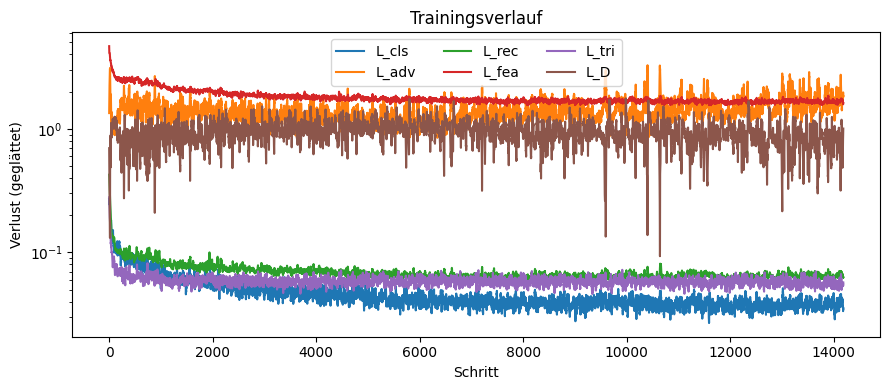

In [11]:
if history['L_cls']:
    fig, ax = plt.subplots(figsize=(9, 4))
    for n, v in history.items():
        ax.plot(np.convolve(v, np.ones(10) / 10, mode='valid'), label=n)
    ax.set_xlabel('Schritt'); ax.set_ylabel('Verlust (geglättet)')
    ax.set_yscale('log'); ax.legend(ncol=3); ax.set_title('Trainingsverlauf')
    plt.tight_layout(); plt.show()

## 8. Quantitative Evaluation

Metriken wie in der MNIST-Version (Sec. 5.2 / Suppl. Tab. 4): Validity, Denoised Validity, Proximity (L1), % Fail, mittleres $k$ des ersten Flips sowie die Faithfulness-Maße $\|\mathbf{z}_k - F(G(\mathbf{z}_k))\|_1$ und $|\sigma(\mathbf{z}_k)_t - \sigma(F(G(\mathbf{z}_k)))_t|$ — ausgewertet auf korrekt klassifizierten Testbildern (beide Richtungen No Finding ↔ Infiltration).

In [12]:
def mirror_generate(x_s, y_s, y_t, ks):
    """Erzeugt zu einem Batch KFE-Bilder fuer alle Schrittfaktoren in ks."""
    with torch.no_grad():
        feats_s = clf.features(x_s)
    f_s4 = feats_s[3]
    f_r4 = compute_reflection(clf, f_s4, y_s, y_t)
    outs, lat = [], []
    with torch.no_grad():
        for kv in ks:
            k = torch.full((x_s.size(0),), float(kv), device=device)
            f_k4 = kfe_feature(f_s4, f_r4, k)
            outs.append(gen(feats_s, f_k4, y_s, y_t, k, W_fc))
            lat.append(f_k4.mean((2, 3)))
    return outs, lat


gen.eval()
ks_scan = np.linspace(0.5, 1.0, 6)
max_eval = 128 if QUICK_TEST else 512
agg = dict(val=[], dval=[], prox=[], prox1=[], fea=[], conf=[], k1st=[], fail=0, n=0)

for x_s, y_s in pair_test_loader:
    if agg['n'] >= max_eval:
        break
    x_s, y_s = x_s.to(device), y_s.to(device)
    with torch.no_grad():
        keep = clf(x_s).argmax(1) == y_s
    x_s, y_s = x_s[keep], y_s[keep]
    if len(x_s) == 0:
        continue
    y_t = 1 - y_s

    outs, lat = mirror_generate(x_s, y_s, y_t, ks_scan)
    with torch.no_grad():
        preds = torch.stack([clf(o).argmax(1) for o in outs])        # (K, B)
        hit = preds == y_t.unsqueeze(0)
        any_hit = hit.any(0)
        first = hit.float().argmax(0)

        x_r, z_r = outs[-1], lat[-1]                                 # Reflexionspunkt k=1
        p_hat = torch.softmax(clf.base.fc(clf.encode(x_r)), 1)
        p_int = torch.softmax(clf.base.fc(z_r), 1)
        arB = torch.arange(len(x_s), device=device)

        agg['val'].append((preds[-1] == y_t).float().cpu())
        agg['dval'].append((clf(TF.gaussian_blur(x_r, 5)).argmax(1) == y_t).float().cpu())
        agg['prox'].append(((x_r - x_s).abs().mean((1, 2, 3)) / 2).cpu())   # [0,1]-Skala
        x_stack = torch.stack(outs)
        x_1st = x_stack[first, arB]
        agg['prox1'].append((((x_1st - x_s).abs().mean((1, 2, 3)) / 2)[any_hit]).cpu())
        agg['fea'].append((z_r - clf.encode(x_r)).abs().mean(1).cpu())
        agg['conf'].append((p_int[arB, y_t] - p_hat[arB, y_t]).abs().cpu())
        agg['k1st'].append(torch.tensor(ks_scan)[first.cpu()][any_hit.cpu()])
        agg['fail'] += int((~any_hit).sum())
        agg['n'] += len(x_s)

cat = {k: torch.cat(v) for k, v in agg.items() if isinstance(v, list)}
print(f'Ausgewertete Testbilder: {agg["n"]}')
print(f'  Validity (k=1):            {cat["val"].mean():.3f}')
print(f'  Denoised Validity (k=1):   {cat["dval"].mean():.3f}')
print(f'  Proximity L1 (k=1):        {cat["prox"].mean():.3f}')
print(f'  Proximity L1 (1st CFE):    {cat["prox1"].mean():.3f}')
print(f'  % Fail (kein Flip):        {100 * agg["fail"] / agg["n"]:.1f} %')
print(f'  mittleres k des 1st CFE:   {cat["k1st"].float().mean():.2f}')
print(f'  Faithfulness  L_fea (L1):  {cat["fea"].mean():.4f}')
print(f'  Faithfulness  L_conf_L1:   {cat["conf"].mean():.4f}')

Ausgewertete Testbilder: 547
  Validity (k=1):            0.832
  Denoised Validity (k=1):   0.810
  Proximity L1 (k=1):        0.061
  Proximity L1 (1st CFE):    0.055
  % Fail (kein Flip):        10.6 %
  mittleres k des 1st CFE:   0.65
  Faithfulness  L_fea (L1):  0.0844
  Faithfulness  L_conf_L1:   0.1270


## 8b. Erweiterte Metriken (wie in der bisherigen Pipeline)

Zusätzlich zu den Paper-Metriken oben die vollständige Metrik-Suite aus `mirrorcfe-xray.ipynb`, ausgewertet am **1st CFE** (pro Sample das kleinste $k$, bei dem das dekodierte Bild flippt; ohne Flip Rückfall auf $k{=}1$) über einen **festen Eval-Satz** (Seed 42, zur Hälfte Infiltration-Bilder mit Bounding-Box):

- **L1-Distanz** (Wachter et al. 2017) und **Sparsity Rate** (Moreira et al. 2025, Anteil veränderter Pixel, Schwelle $10^{-4}$) — ↓ besser
- **LPIPS** (Zhang et al. 2018, SqueezeNet wie im Paper) — ↓ besser; benötigt `pip install lpips`, wird sonst übersprungen
- **FID** (InceptionV3-Features, 2048-dim) — ↓ besser
- **EBPG** (Energy-Based Pointing Game, Wang et al. 2019): Anteil der Differenz-Energie innerhalb der GT-Bounding-Box — ↑ besser
- **Validity / Denoised Validity** (Verma et al. 2022; Gaussian Blur $\sigma{=}1$) und **Δ Validity** — ↑ / ↑ / ↓ besser
- **Coverage** (Moreira et al. 2025): Flip-Rate am 1st CFE — in dieser Pipeline deterministisch, daher identisch über Runs
- **Efficiency**: Sekunden pro erzeugtem CF

In [13]:
# Infiltration-Bounding-Boxen aus BBox_List_2017.csv - identisch zur Vorlage
bbox_df = pd.read_csv(os.path.join(DATA_DIR, 'BBox_List_2017.csv'))
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
bbox_df = bbox_df[bbox_df['Finding Label'] == 'Infiltration']

scale = IMG / 1024.0                # NIH-Originale sind 1024x1024
bbox_lookup = {}
for _, r in bbox_df.iterrows():     # erste Infiltration-Box je Bild (wie Vorlage)
    bbox_lookup.setdefault(r['Image Index'], {
        'x': r['x'] * scale, 'y': r['y'] * scale,
        'w': r['w'] * scale, 'h': r['h'] * scale})
print(f'Infiltration-BBoxen geladen: {len(bbox_lookup)} Bilder')

BBOX_CLASS = 1                      # Infiltration-Bilder haben BBoxen
eval_pool  = list(range(len(test_ds)))   # Evaluation auf dem Test-Split

def eval_fname(i): return test_df.iloc[i]['Image Index']
def eval_label(i): return test_ds.targets[i]
def eval_image(i): return test_ds[i][0]

Infiltration-BBoxen geladen: 0 Bilder


In [14]:
import time
from scipy import linalg as scipy_linalg
from torchvision.models import inception_v3

try:                                # LPIPS optional (pip install lpips)
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(device); lpips_fn.eval()
    LPIPS_AVAILABLE = True
except ImportError:
    LPIPS_AVAILABLE = False
    print('lpips nicht verfuegbar - Metrik wird uebersprungen (pip install lpips)')


def first_cfe_images(x_s, y_s, y_t, k_grid=None):
    """Pro Sample das dekodierte Bild am kleinsten flippenden k ('1st CFE');
       ohne Flip Rueckfall auf k=1. Rueckgabe: Bilder [-1,1], k_used, found."""
    if k_grid is None:
        k_grid = [0.55 + 0.05 * i for i in range(10)]     # 0.55 .. 1.0 (wie Vorlage)
    with torch.no_grad():
        feats_s = clf.features(x_s)
    f_s4 = feats_s[3]
    f_r4 = compute_reflection(clf, f_s4, y_s, y_t)
    n = x_s.size(0)
    found  = torch.zeros(n, dtype=torch.bool, device=device)
    k_used = torch.ones(n, device=device)
    best = None
    with torch.no_grad():
        for kv in k_grid:
            k  = torch.full((n,), float(kv), device=device)
            xk = gen(feats_s, kfe_feature(f_s4, f_r4, k), y_s, y_t, k, W_fc)
            pred = clf(xk).argmax(1)
            if best is None:
                best = xk.clone()
            newly = (pred == y_t) & (~found)
            best[newly] = xk[newly]
            k_used[newly] = kv
            found |= newly
            if found.all():
                break
        if (~found).any():
            k   = torch.ones(n, device=device)
            xk1 = gen(feats_s, kfe_feature(f_s4, f_r4, k), y_s, y_t, k, W_fc)
            best[~found] = xk1[~found]
    return best, k_used, found


def to01(x):
    """[-1,1]-Tensor -> (B,H,W,3)-NumPy in [0,1]."""
    return ((x + 1) / 2).clamp(0, 1).permute(0, 2, 3, 1).cpu().numpy()

def compute_l1(orig_np, cfe_np):
    """L1 nach Wachter et al. (2017), pro Pixel/Kanal gemittelt."""
    return float(np.abs(orig_np - cfe_np).mean(axis=(1, 2, 3)).mean())

def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """Anteil veraenderter Pixel (Moreira et al. 2025)."""
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    return float((diff > threshold).astype(float).mean(axis=(1, 2)).mean())

def compute_lpips(orig_np, cfe_np):
    """LPIPS (Zhang et al. 2018), SqueezeNet wie im Paper."""
    if not LPIPS_AVAILABLE:
        return None
    o = torch.tensor(orig_np, dtype=torch.float32).permute(0, 3, 1, 2).to(device) * 2 - 1
    c = torch.tensor(cfe_np,  dtype=torch.float32).permute(0, 3, 1, 2).to(device) * 2 - 1
    with torch.no_grad():
        return float(lpips_fn(o, c).mean().cpu())

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """2048-dim InceptionV3-Features fuer FID; imgs_np (B,H,W,3) in [0,1]."""
    if not hasattr(extract_inception_features, '_model'):
        m = inception_v3(weights='DEFAULT', transform_input=False)
        m.fc = nn.Identity()
        extract_inception_features._model = m.eval().to(device)
    inc = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        t = torch.tensor(imgs_np[i:i + batch_size], dtype=torch.float32)
        t = t.permute(0, 3, 1, 2).to(device)
        t = F.interpolate(t, size=(299, 299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)

def compute_fid(real_np, fake_np):
    """FID ueber InceptionV3-Features."""
    fr, ff = extract_inception_features(real_np), extract_inception_features(fake_np)
    mu_r, mu_f = fr.mean(0), ff.mean(0)
    sig_r = np.cov(fr, rowvar=False)
    sig_f = np.cov(ff, rowvar=False)
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    d = mu_r - mu_f
    return float(d @ d + np.trace(sig_r + sig_f - 2 * covmean))

def compute_ebpg(orig_np, cfe_np, bboxes_pixel):
    """Energy-Based Pointing Game (Wang et al. 2019) auf dem Differenzbild."""
    scores = []
    for i, b in enumerate(bboxes_pixel):
        diff = np.abs(cfe_np[i] - orig_np[i]).mean(axis=-1)
        x1, y1 = max(0, int(b['x'])), max(0, int(b['y']))
        x2 = min(IMG, int(b['x'] + b['w']))
        y2 = min(IMG, int(b['y'] + b['h']))
        scores.append(diff[y1:y2, x1:x2].sum() / (diff.sum() + 1e-8))
    return float(np.mean(scores)) if scores else None

def compute_validity_01(cfe01_tensor, target_labels, denoise_sigma=None):
    """Validity (Verma et al. 2022); optional Denoised Validity via Gaussian Blur."""
    x = cfe01_tensor.to(device)
    if denoise_sigma is not None:
        ksz = max(int(denoise_sigma * 6) | 1, 3)
        x = TF.gaussian_blur(x, kernel_size=[ksz, ksz],
                             sigma=[denoise_sigma, denoise_sigma])
    with torch.no_grad():
        preds = clf(x * 2 - 1).argmax(1).cpu()    # [0,1] -> [-1,1]-Eingabedomaene
    return float((preds == target_labels.cpu()).float().mean())

print('Metrik-Funktionen definiert')

lpips nicht verfuegbar - Metrik wird uebersprungen (pip install lpips)
Metrik-Funktionen definiert


In [15]:
# Fester Eval-Satz (Seed 42): zur Haelfte BBox-Bilder der Zielklasse - wie Vorlage
EVAL_SEED     = 42
N_EVAL_IMAGES = 32 if QUICK_TEST else 80
DENOISE_SIGMA = 1.0
gen.eval()

idx_bbox = [i for i in eval_pool
            if eval_label(i) == BBOX_CLASS and eval_fname(i) in bbox_lookup]
idx_rest = [i for i in eval_pool
            if not (eval_label(i) == BBOX_CLASS and eval_fname(i) in bbox_lookup)]
rng = np.random.RandomState(EVAL_SEED)
rng.shuffle(idx_bbox); rng.shuffle(idx_rest)
n_bbox = min(len(idx_bbox), N_EVAL_IMAGES // 2)
sel = idx_bbox[:n_bbox] + idx_rest[:N_EVAL_IMAGES - n_bbox]
rng2 = np.random.RandomState(EVAL_SEED)
rng2.shuffle(sel)
eval_indices = sel[:N_EVAL_IMAGES]
print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (davon {n_bbox} mit BBox)')

all_l1, all_sparsity, all_lpips, all_ebpg = [], [], [], []
all_real, all_cfe, all_cfe_t, all_tgt = [], [], [], []
total_time, n_images = 0.0, 0

for c0 in range(0, len(eval_indices), 32):
    chunk = eval_indices[c0:c0 + 32]
    x_s = torch.stack([eval_image(i) for i in chunk]).to(device)
    with torch.no_grad():
        y_s = clf(x_s).argmax(1)          # modellprognostizierte Quelle (wie Vorlage)
    y_t = 1 - y_s

    t0 = time.time()
    x_cfe, k_used, found = first_cfe_images(x_s, y_s, y_t)
    total_time += time.time() - t0
    n_images += len(chunk)

    orig01, cfe01 = to01(x_s), to01(x_cfe)
    all_l1.append(compute_l1(orig01, cfe01))
    all_sparsity.append(compute_sparsity_rate(orig01, cfe01))
    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig01, cfe01))
    all_real.append(orig01); all_cfe.append(cfe01)
    all_cfe_t.append(torch.tensor(cfe01, dtype=torch.float32).permute(0, 3, 1, 2))
    all_tgt.append(y_t.cpu())

    boxes, keep = [], []
    for j, i in enumerate(chunk):
        if eval_label(i) == BBOX_CLASS and eval_fname(i) in bbox_lookup:
            boxes.append(bbox_lookup[eval_fname(i)]); keep.append(j)
    if boxes:
        e = compute_ebpg(orig01[keep], cfe01[keep], boxes)
        if e is not None:
            all_ebpg.append(e)

fid_score = compute_fid(np.concatenate(all_real), np.concatenate(all_cfe))
cfe_t_cat, tgt_cat = torch.cat(all_cfe_t), torch.cat(all_tgt)
validity   = compute_validity_01(cfe_t_cat, tgt_cat)
d_validity = compute_validity_01(cfe_t_cat, tgt_cat, denoise_sigma=DENOISE_SIGMA)
# Coverage (Moreira et al. 2025): Flip-Rate am 1st CFE. Die Pipeline ist
# deterministisch (analytische Spiegelung + eval()-Generator), daher ohne
# Mehrfach-Runs identisch zur Validity-Definition der Vorlage.
coverage   = validity
efficiency = total_time / n_images

print('\n' + '=' * 60)
print('METRIK-ERGEBNISSE - Mirror-CFE (1st CFE, fester Eval-Satz)')
print('=' * 60)
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}   (v besser)')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}   (v besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}   (v besser)')
print(f'  FID:                  {fid_score:.2f}    (v besser)')
if all_ebpg:
    print(f'  EBPG:                 {np.mean(all_ebpg):.4f}   (^ besser)')
print(f'  Validity:             {validity:.2%}   (^ besser)')
print(f'  Denoised Validity:    {d_validity:.2%}   (^ besser, sigma={DENOISE_SIGMA})')
print(f'  Delta Validity:       {validity - d_validity:.2%}   (v besser)')
print(f'  Coverage:             {coverage:.2%}   (^ besser, deterministisch)')
print(f'  Efficiency:           {efficiency:.3f} s / CF   (v besser)')
print('=' * 60)

Fester Eval-Satz: 80 Bilder (davon 0 mit BBox)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 189MB/s] 
/tmp/ipykernel_23/2903491108.py:91: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)



METRIK-ERGEBNISSE - Mirror-CFE (1st CFE, fester Eval-Satz)
  L1-Distanz:           0.0487   (v besser)
  Sparsity Rate:        0.9984   (v besser)
  FID:                  116.08    (v besser)
  Validity:             87.50%   (^ besser)
  Denoised Validity:    68.75%   (^ besser, sigma=1.0)
  Delta Validity:       18.75%   (v besser)
  Coverage:             87.50%   (^ besser, deterministisch)
  Efficiency:           0.040 s / CF   (v besser)


## 8c. Ansicht: Original — CF — Differenz (mit Bounding-Box)

Wie in der bisherigen Pipeline: Für Eval-Bilder der BBox-Klasse werden Original (mit GT-Box), 1st-CFE-Bild und das Differenzbild $|\mathbf{x}_{cf} - \mathbf{x}_s|$ nebeneinander gezeigt; die Box ist auch im Differenzbild eingezeichnet, dazu der EBPG-Wert des Samples. Konzentriert sich die Differenz-Energie in der Box, ändert Mirror-CFE genau die annotierte (radiologisch markierte) Region.

In [16]:
import matplotlib.patches as patches

def draw_bbox(ax, b, color='yellow'):
    ax.add_patch(patches.Rectangle((b['x'], b['y']), b['w'], b['h'],
                 linewidth=2, edgecolor=color, facecolor='none', linestyle='--'))

show_idx = [i for i in eval_indices
            if eval_label(i) == BBOX_CLASS and eval_fname(i) in bbox_lookup][:6]
if not show_idx:
    print('Keine BBox-Bilder im Eval-Satz.')
else:
    x_s = torch.stack([eval_image(i) for i in show_idx]).to(device)
    with torch.no_grad():
        y_s = clf(x_s).argmax(1)
    y_t = 1 - y_s
    x_cfe, k_used, found = first_cfe_images(x_s, y_s, y_t)
    with torch.no_grad():
        p_t = torch.softmax(clf(x_cfe), 1)[torch.arange(len(show_idx)), y_t]
    orig01, cfe01 = to01(x_s), to01(x_cfe)

    names = CFG['class_names']
    fig, axes = plt.subplots(len(show_idx), 3, figsize=(9.5, 3.1 * len(show_idx)))
    axes = np.atleast_2d(axes)
    for r, i in enumerate(show_idx):
        b = bbox_lookup[eval_fname(i)]
        diff = np.abs(cfe01[r] - orig01[r]).mean(axis=-1)
        ebpg_i = compute_ebpg(orig01[r:r+1], cfe01[r:r+1], [b])

        axes[r, 0].imshow(orig01[r]); draw_bbox(axes[r, 0], b)
        axes[r, 0].set_title(f'Original: {names[int(y_s[r])]}', fontsize=9)
        axes[r, 1].imshow(cfe01[r])
        axes[r, 1].set_title(f'1st CFE (k={k_used[r]:.2f})\n'
                             f'p({names[int(y_t[r])]}) = {p_t[r]:.2f}', fontsize=9)
        im = axes[r, 2].imshow(diff, cmap='hot'); draw_bbox(axes[r, 2], b, 'cyan')
        axes[r, 2].set_title(f'|Differenz|  EBPG = {ebpg_i:.2f}', fontsize=9)
        for a in axes[r]:
            a.axis('off')
    fig.suptitle('Original - CF - Differenz (GT-Bounding-Box gestrichelt)', y=1.005)
    plt.tight_layout(); plt.show()

Keine BBox-Bilder im Eval-Satz.


## 9. Visualisierung des CFE-Übergangs

Übergang $k = 0 \to 1$ für je ein Beispiel pro Richtung (No Finding → Infiltration und Infiltration → No Finding). Unter jedem Bild: **vorhergesagte / intendierte** Zielklassen-Konfidenz. Für Infiltration → No Finding sollten die Verschattungen im Lungenfeld schrittweise verschwinden.

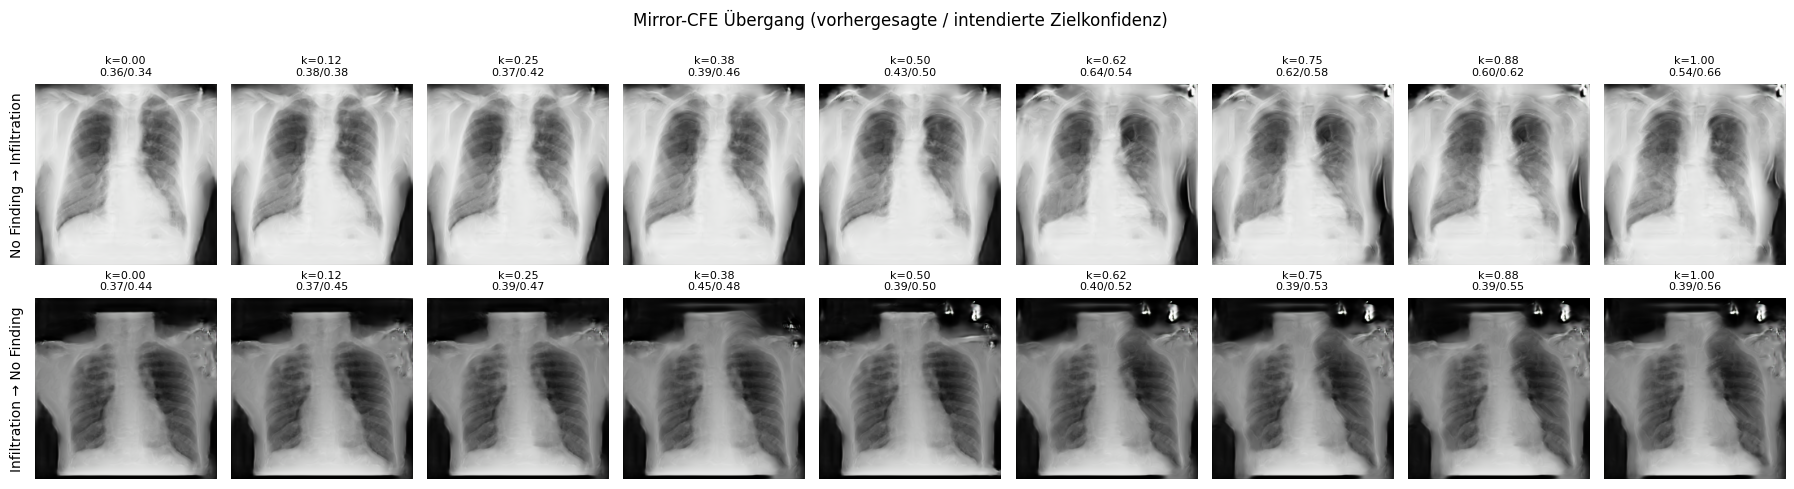

In [17]:
def show_img(ax, x):
    ax.imshow(((x * 0.5 + 0.5).clamp(0, 1)).permute(1, 2, 0).cpu().numpy())
    ax.axis('off')

# je ein korrekt klassifiziertes Beispiel pro Richtung suchen
vis = []
with torch.no_grad():
    for src_cls in (0, 1):
        for x_b, y_b in pair_test_loader:
            found = False
            for j in range(len(y_b)):
                if int(y_b[j]) == src_cls:
                    xj = x_b[j].unsqueeze(0).to(device)
                    if clf(xj).argmax(1).item() == src_cls:
                        vis.append((x_b[j], src_cls, 1 - src_cls))
                        found = True
                        break
            if found:
                break

ks_vis = np.linspace(0, 1, 9)
fig, axes = plt.subplots(len(vis), len(ks_vis), figsize=(2.0 * len(ks_vis), 2.4 * len(vis)))
axes = np.atleast_2d(axes)

names = CFG['class_names']
for row, (x, s, t) in enumerate(vis):
    x_s = x.unsqueeze(0).to(device)
    y_s = torch.tensor([s], device=device)
    y_t = torch.tensor([t], device=device)
    outs, lat = mirror_generate(x_s, y_s, y_t, ks_vis)
    with torch.no_grad():
        for col, (kv, o, z) in enumerate(zip(ks_vis, outs, lat)):
            p_hat = torch.softmax(clf(o), 1)[0, t].item()
            p_int = torch.softmax(clf.base.fc(z), 1)[0, t].item()
            axm = axes[row, col]
            show_img(axm, o[0])
            axm.set_title(f'k={kv:.2f}\n{p_hat:.2f}/{p_int:.2f}', fontsize=8)
    axes[row, 0].text(-0.1, 0.5, f'{names[s]} → {names[t]}', rotation=90,
                      va='center', ha='center', transform=axes[row, 0].transAxes)
fig.suptitle('Mirror-CFE Übergang (vorhergesagte / intendierte Zielkonfidenz)', y=1.02)
plt.tight_layout(); plt.show()

**Animierter Übergang** (No Finding → Infiltration) als GIF, wie die Videos im Supplementary Material.

Animation gespeichert: mirror_cfe_xray_transition.gif


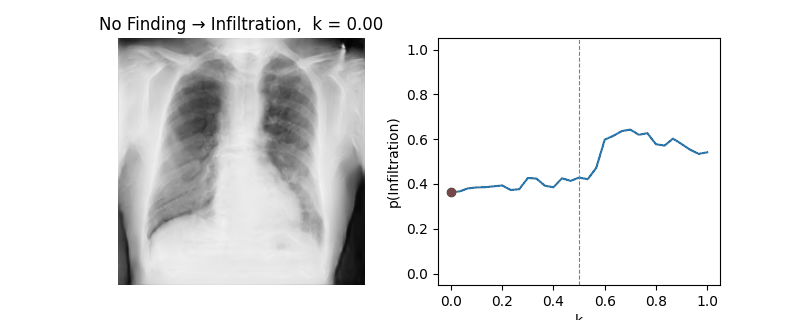

In [18]:
from matplotlib.animation import FuncAnimation, PillowWriter

x, s, t = vis[0]
x_s = x.unsqueeze(0).to(device)
y_s = torch.tensor([s], device=device)
y_t = torch.tensor([t], device=device)
ks_anim = np.linspace(0, 1, 31)
outs, lat = mirror_generate(x_s, y_s, y_t, ks_anim)
with torch.no_grad():
    confs = [torch.softmax(clf(o), 1)[0, t].item() for o in outs]

fig, (ax_img, ax_plot) = plt.subplots(1, 2, figsize=(8, 3.2))
im = ax_img.imshow(((outs[0][0] * 0.5 + 0.5).clamp(0, 1)).permute(1, 2, 0).cpu().numpy())
ax_img.axis('off')
ax_plot.plot(ks_anim, confs, color='tab:blue')
pt, = ax_plot.plot([], [], 'ro')
ax_plot.axvline(0.5, color='gray', ls='--', lw=0.8)
ax_plot.set_xlabel('k'); ax_plot.set_ylabel(f'p({CFG["class_names"][t]})')
ax_plot.set_ylim(-0.05, 1.05)

def update(i):
    im.set_data(((outs[i][0] * 0.5 + 0.5).clamp(0, 1)).permute(1, 2, 0).cpu().numpy())
    ax_img.set_title(f'{CFG["class_names"][s]} → {CFG["class_names"][t]},  k = {ks_anim[i]:.2f}')
    pt.set_data([ks_anim[i]], [confs[i]])
    return im, pt

anim = FuncAnimation(fig, update, frames=len(ks_anim), interval=120)
gif_path = 'mirror_cfe_xray_transition.gif'
anim.save(gif_path, writer=PillowWriter(fps=8))
plt.close(fig)
print(f'Animation gespeichert: {gif_path}')

from IPython.display import Image as IPImage
IPImage(gif_path)

## 10. Anmerkungen & Designentscheidungen

Zusätzlich zu den Punkten aus der MNIST-Version (CPU-L-BFGS, schlankes SPE, alternierende Rekonstruktion, $\rho$-Bereich $[0.3, 0.8]$, Adam-Betas $(0.5, 0.999)$); die Metrik-Suite der bisherigen Pipeline inkl. FID/LPIPS/EBPG ist in Sec. 8b/8c enthalten:

1. **Klassendefinition und Split wie in der Vorlage:** `No Finding` = 0, Befunde mit `Infiltration` = 1 (Mehrfachbefunde mit Infiltration eingeschlossen, alle anderen verworfen); patientenbasierter 70/15/15-Split mit `GroupShuffleSplit(random_state=42)` — beides identisch zu `mirrorcfe-xray.ipynb`, damit die Ergebnisse vergleichbar sind.
2. **Eigener Klassifikator statt Kaggle-Checkpoint:** Diese Implementierung trainiert ihren torchvision-ResNet-18 selbst (der Kaggle-Checkpoint `resnet18_xray_final.pth` hat eine inkompatible eigene ResNet-Implementierung). Dadurch genügt die $[-1,1]$-Normierung statt ImageNet-Statistiken. Hinweis: Die Klassen sind unbalanciert (~3:1 No Finding : Infiltration) und die Aufgabe ist deutlich schwerer als fire/no_fire — die Genauigkeit des binären Klassifikators liegt typischerweise nur bei ~70–80 %; die Per-Klassen-Genauigkeit wird mit ausgegeben.
3. **Bildgröße 224** wie in der bestehenden Kaggle-Pipeline (Feature-Map 512×7×7). Auf schwacher Hardware kann `img_size = 128` gesetzt werden (wie im Paper für B-MNIST; Feature-Map 512×4×4 — der Code ist größenunabhängig).
4. **Binärer Fall:** Die L-BFGS-Verfeinerung ist hier ein No-Op (die Spiegelung erfüllt die Logit-Tausch-Bedingung exakt); der Codepfad bleibt zur Konsistenz erhalten.
5. **Subtile Klassenunterschiede:** Anders als bei MNIST/Fire sind die visuellen Unterschiede (diffuse Verschattungen) klein und der Klassifikator ist schwächer — CFEs erben die Unsicherheit des Klassifikators (Faithfulness heißt hier: das Notebook erklärt *diesen* Klassifikator, nicht die medizinische Wahrheit). Die Bounding-Box-basierten Analysen der Vorlage (`BBox_List_2017.csv`, EBPG, Original/CF/Differenz-Ansicht) sind in Sec. 8b/8c enthalten.